In [1]:
import os
import re
from collections import defaultdict
import numpy as np
from tensorboard.backend.event_processing import event_accumulator
import matplotlib.pyplot as plt
import pickle

def get_dirs(pattern, root_dir='../runs'):
    matching_dirs = []

    for dirpath, _, _ in os.walk(root_dir):
        rel_path = os.path.relpath(dirpath, root_dir)
        if pattern.search(rel_path):
            matching_dirs.append(os.path.join(root_dir, rel_path))

    print("Matched directories:")
    for path in matching_dirs:
        print(path)
    
    return matching_dirs


def extract_scalars(event_file: str, tag: str):
    """
    Read one TensorBoard event file and pull out all (step, value, wall_time) triples
    for the scalar `tag`. Returns three parallel lists: (steps, values, wall_times).

    Raises:
        ValueError if `tag` is not present in that event file.
    """
    ea = event_accumulator.EventAccumulator(
        event_file,
        size_guidance={"scalars": 0}  # 0 → load all scalar events
    )
    ea.Reload()

    available_tags = ea.Tags().get("scalars", [])
    if tag not in available_tags:
        raise ValueError(
            f"Tag {tag!r} not found in {os.path.basename(event_file)}. "
            f"Available scalar tags are: {available_tags}"
        )

    events = ea.Scalars(tag)
    steps      = [e.step      for e in events]
    values     = [e.value     for e in events]
    wall_times = [e.wall_time for e in events]
    return steps, values, wall_times

def parse_seed(dir):
    """
    Given a path that ends in '_s<digit>' (e.g. '..._s2/tensorboard_logs'),
    return the integer seed. Raises ValueError if no '_sN' is found.
    """
    exp = dir.split('/')[-2]
    m = re.compile(r"_s([0-9]+)")
    if m.search(exp):
        return int(exp.split('_')[-1][-1])
    else:
        raise ValueError(f"Cannot find a seed in directory name: {dir!r}")
        

def collect_scalar(matching_dirs, tag):
    """
    For each directory in matching_dirs, locate the TensorBoard event file,
    extract (steps, values) for `tag`, and store them in a dict keyed by seed.
    Verifies all seeds share the same 'steps' array; if not, raises an error.

    Returns:
        data_dict: Dict[int → (np.ndarray steps, np.ndarray values)]
    """
    data_dict = {}

    for run_dir in matching_dirs:

        steps, values, _ = extract_scalars(run_dir, tag)

        steps_arr  = np.array(steps, dtype=int)
        values_arr = np.array(values, dtype=float)

        data_dict[run_dir] = (steps_arr, values_arr)

    return data_dict


def _collect_scalar_over_seeds(matching_dirs, tag):
    """
    For each directory in matching_dirs, locate the TensorBoard event file,
    extract (steps, values) for `tag`, and store them in a dict keyed by seed.
    Verifies all seeds share the same 'steps' array; if not, raises an error.

    Returns:
        data_dict: Dict[int → (np.ndarray steps, np.ndarray values)]
    """
    data_dict = {}
    common_steps = None

    for run_dir in matching_dirs:
        seed = parse_seed(run_dir)
        steps, values, _ = extract_scalars(run_dir, tag)

        steps_arr  = np.array(steps, dtype=int)
        values_arr = np.array(values, dtype=float)

        if common_steps is None:
            common_steps = steps_arr
        else:
            # enforce that steps match exactly
            if not np.array_equal(common_steps, steps_arr):
                raise RuntimeError(
                    f"Step arrays do not match for seed {seed}. "
                    f"Got shape {steps_arr.shape}, expected {common_steps.shape}."
                )

        data_dict[seed] = (steps_arr, values_arr)

    return data_dict


def group_curvature_tags(all_scalar_tags):
    """
    Given a list of scalar tags (strings), return a mapping:
      layer_index (int) → [list of full tag strings for that layer, sorted by head index].
    Only tags that match the pattern "Curvature/layer_<i>/head_<j>" are included.

    e.g. input: ["Curvature/layer_0/head_0", "Curvature/layer_0/head_1",
                 "Curvature/layer_1/head_0", ...]
         output: { 0: ["Curvature/layer_0/head_0",
                       "Curvature/layer_0/head_1", …],
                   1: ["Curvature/layer_1/head_0", …], … }
    """
    regex = re.compile(r"^Curvature/layer_([0-9]+)/(head_[0-9]+)$")
    layer_dict = defaultdict(list)

    for tag in all_scalar_tags:
        m = regex.match(tag)
        if m:
            layer_idx = int(m.group(1))
            head_part = m.group(2)  # e.g. "head_0"
            layer_dict[layer_idx].append( (int(head_part.split('_')[1]), tag) )
            # we store (head_index, full_tag) so we can sort by head index

    # Sort by head index inside each layer, then discard the head index
    grouped = {}
    for layer_idx, head_list in layer_dict.items():
        head_list.sort(key=lambda x: x[0])  # sort by head index
        grouped[layer_idx] = [ full_tag for (_h, full_tag) in head_list ]

    return grouped  # Dict[int, List[str]]

def extract_curvature_by_run(run_dir, grouped_tags):
    """
    For one run directory (e.g. '../runs/.../some_s0/tensorboard_logs/'),
    returns a nested dict:

      curvature_data[layer_idx][head_idx] = (steps_array, values_array)

    - `grouped_tags` is the output of group_curvature_tags(all_scalar_tags_for_that_run).
    - We assume each run_dir has exactly one event file.
    - We extract step/value for each 'Curvature/layer_i/head_j' tag.

    Example return structure:
      {
        0: { 0: (steps, values_for_layer0_head0),
             1: (steps, values_for_layer0_head1),
             … },
        1: { 0: (steps, values_for_layer1_head0), … },
        … 
      }
    """
    curvature_data = {}

    for layer_idx, tag_list in grouped_tags.items():
        # For each layer, we'll create an inner dict mapping head_idx → (steps, values)
        curvature_data[layer_idx] = {}
        for full_tag in tag_list:
            # Parse out head index from tag, e.g. "Curvature/layer_3/head_5" → head_idx=5
            h = int(full_tag.split('/')[-1].split('_')[1])

            steps, values, _ = extract_scalars(run_dir, full_tag)
            curvature_data[layer_idx][h] = (np.array(steps, dtype=int),
                                            np.array(values, dtype=float))

    return curvature_data

def get_curvatures(dir):
    ea = event_accumulator.EventAccumulator(dir, size_guidance={'scalars': 0})
    ea.Reload()
    all_tags = ea.Tags().get("scalars", [])
    grouped_tags = group_curvature_tags(all_tags)
    run_curvatures = extract_curvature_by_run(dir, grouped_tags)
    return run_curvatures # nested dict: run0_curvature[layer_idx][head_idx] = (steps, values)

#### Shakespeare

In [2]:
n_heads = 8
n_layers = 8

# curv_of_lr = {}
# last_curv_of_lr = {}

# for lr, k in zip(
#     [1., 3.33, 10., 33.3],
#     ['sh_eh_lr1', 'sh_eh_lr3', 'sh_eh_lr10', 'sh_eh_lr33']
# ):
#     print('\n', lr)
#     pattern = re.compile(f"{k}_402K.*/tensorboard_logs")
#     matching_dirs = get_dirs(pattern)

#     curv_of_seed = {}
#     last_curv_of_seed = {}

#     for dir in matching_dirs:
#         s = parse_seed(dir)
#         print(f"Seed: {s}")
#         curv_dict = get_curvatures(dir)
#         curv_arr = np.array([[curv_dict[l][h][1] for h in range(n_heads)] for l in range(n_layers)])
#         last_curv_arr = np.array([[curv_dict[l][h][1][-1] for h in range(n_heads)] for l in range(n_layers)])
#         curv_of_seed[s] = curv_arr
#         last_curv_of_seed[s] = last_curv_arr

    # curv_of_lr[lr] = curv_of_seed
    # last_curv_of_lr[lr] = last_curv_of_seed

# with open('shakespeare_curvatures.pkl', 'wb') as file:
#     pickle.dump(curv_of_lr, file, protocol=pickle.HIGHEST_PROTOCOL)

In [3]:
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

def plot_layer_curvatures(ax, heads_curv, color='red', title=None, yscale=None, alpha=1., lw=6, step=50):
    steps = np.arange(len(heads_curv[0])) * step
    for values in heads_curv:
        ax.plot(steps, values, color=color, alpha=alpha, lw=lw)
    ax.set_xlabel("Step")
    ax.set_ylabel("Curvature")
    if title is not None:
        ax.set_title(title)
    if yscale is not None:
        ax.set_yscale(yscale)
    ax.grid(True)

In [4]:
with open('shakespeare_curvatures.pkl', 'rb') as file:
    curv_of_lr = pickle.load(file)

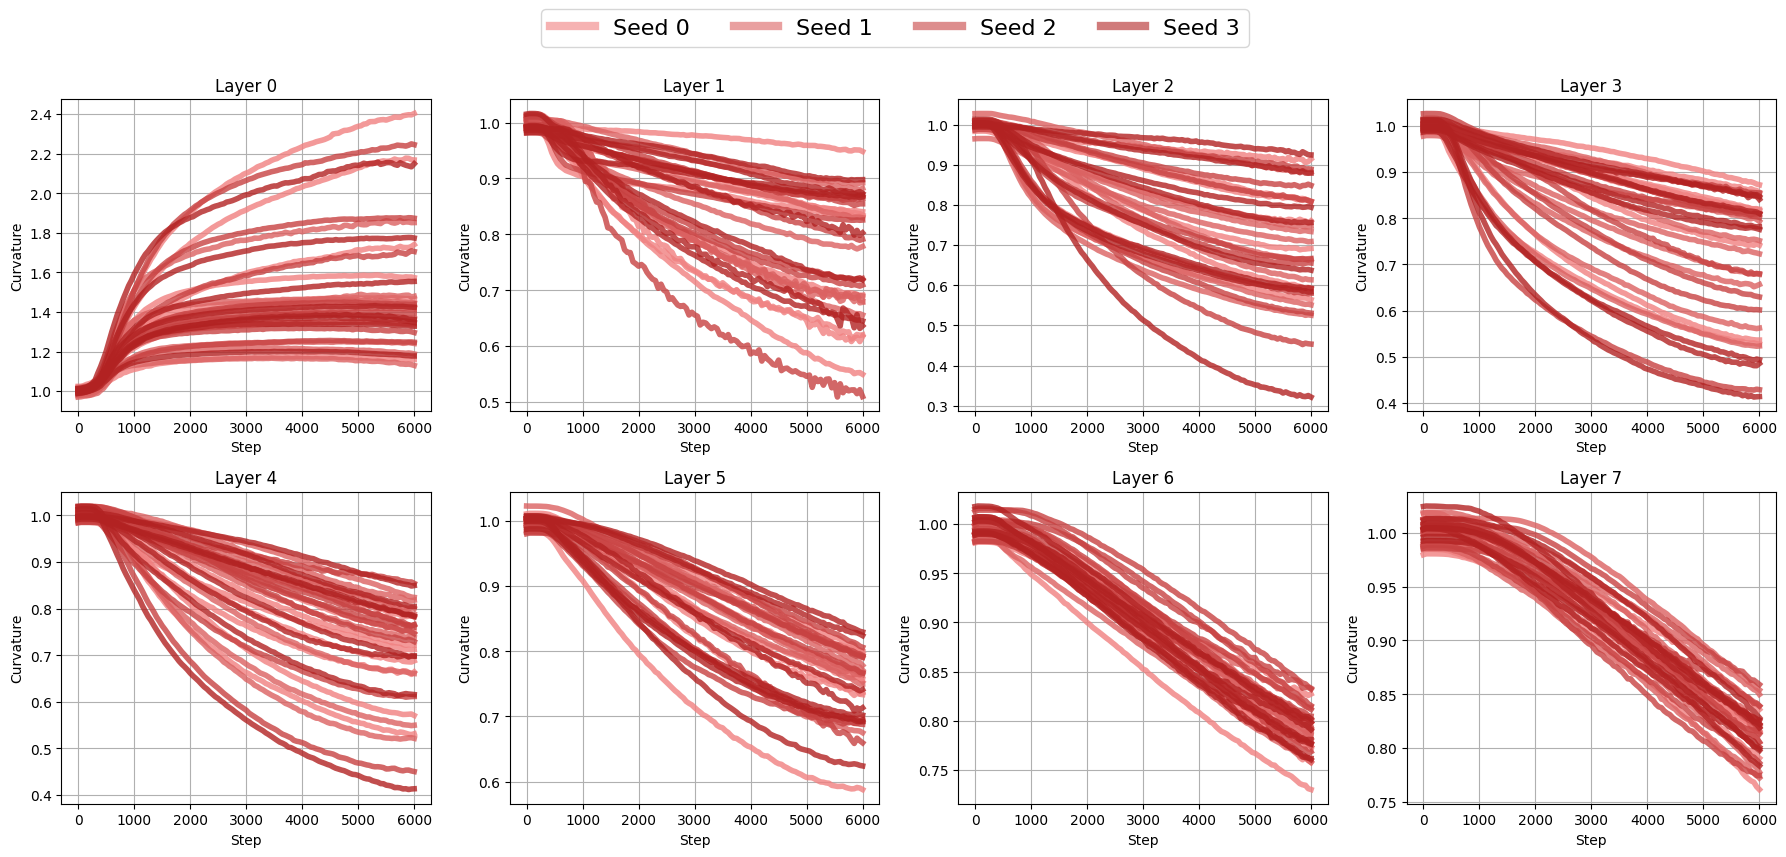

In [5]:
EUC_COLOR = 'lightcoral'
HYP_COLOR = 'firebrick'

euc_rgb = mcolors.to_rgb(EUC_COLOR)  
hyp_rgb = mcolors.to_rgb(HYP_COLOR)     

def color_space(num_colors, euc=EUC_COLOR, hyp=HYP_COLOR): 
    euc_rgb = mcolors.to_rgb(euc)  
    hyp_rgb = mcolors.to_rgb(hyp)    
    return [
    tuple((1 - t) * e + t * h for e, h in zip(euc_rgb, hyp_rgb))
    for t in np.linspace(0, 1, num_colors)
]

colors = color_space(4)

curv_of_seed = curv_of_lr[1.]

fig, axs = plt.subplots(2, 4, figsize=(18, 8))
axs = axs.flatten()
for layer, ax in enumerate(axs):
    for s, c in enumerate(colors):
        plot_layer_curvatures(ax, curv_of_seed[s][layer], title=f"Layer {layer}", color=c, alpha=0.8, lw=4)

seed_labels = [f"Seed {s}" for s in range(4)]

legend_handles = [
    Line2D([0], [0], color=c, lw=6, alpha=0.6, label=label)
    for c, label in zip(colors, seed_labels)
]

fig.legend(handles=legend_handles, loc='upper center', ncol=4, fontsize=16, bbox_to_anchor=(0.5, 1.08))

plt.tight_layout()
plt.show()

In [6]:
n_layers = 8
n_heads = 8

last_curv = np.empty((n_layers, n_heads))

lr = 1.
s = 0
for l in range(n_layers):
    for h in range(n_heads):
        last_curv[l, h] = curv_of_lr[lr][s][l][h][-1]

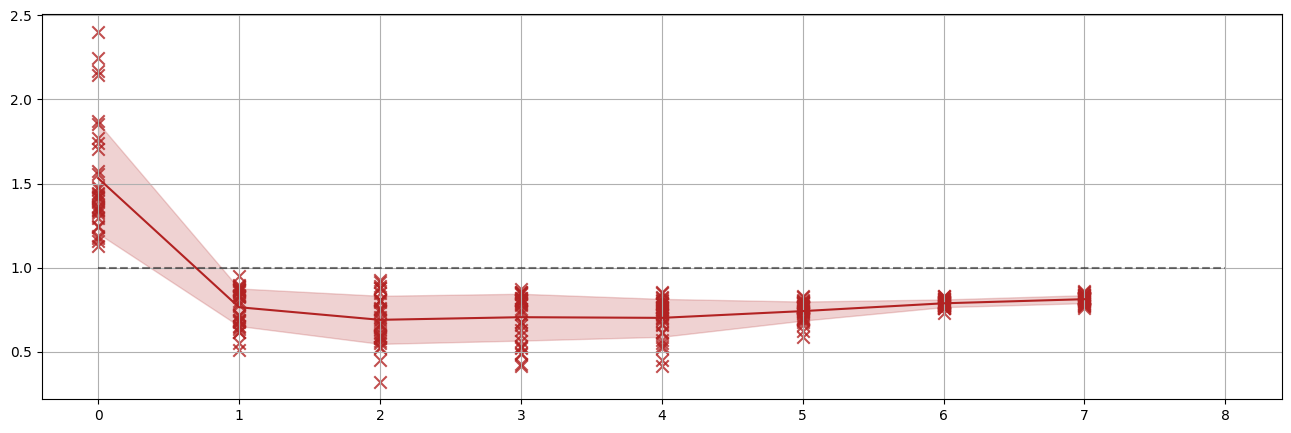

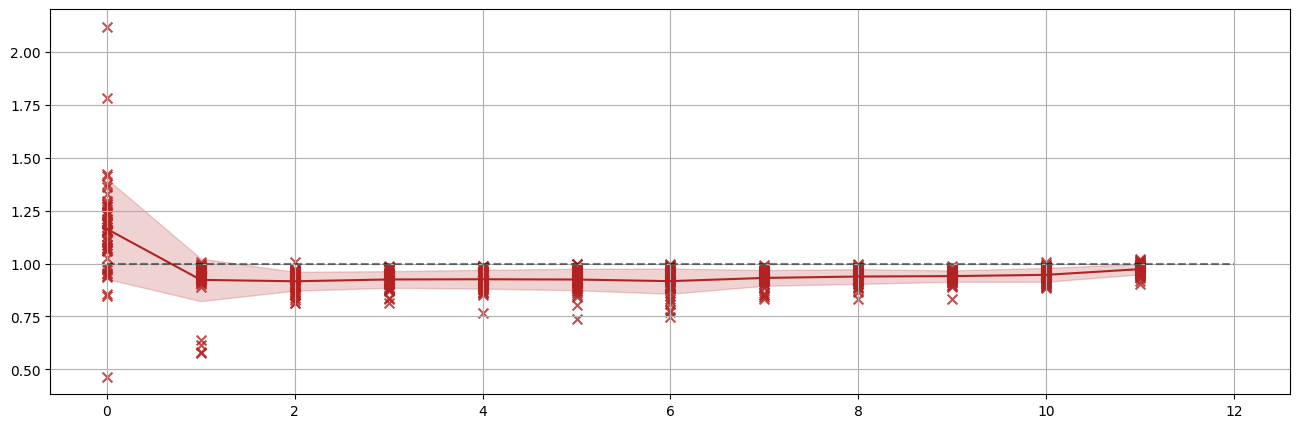

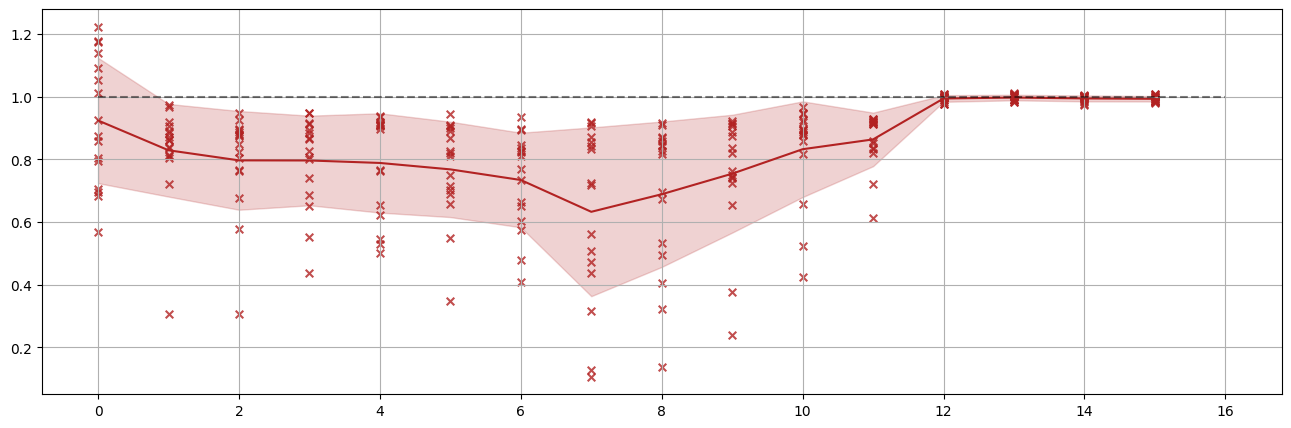

In [7]:
def get_last_curv(curv_dict, n_layers, n_heads):
    last_curv = np.empty((n_layers, n_heads))

    for l in range(n_layers):
        for h in range(n_heads):
            last_curv[l, h] = curv_dict[l][h][-1]
    return last_curv

def get_last_curv_merged(curv_dict, n_layers, n_heads, n_seeds=4):
    last_curv = np.empty((n_layers, n_seeds * n_heads))

    for l in range(n_layers):
        for h in range(n_heads):
            for s in range(n_seeds):
                i = int(n_heads * s + h)  
                last_curv[l, i] = curv_dict[s][l][h][-1]
            
    return last_curv  

def plot_curv_over_layers(ax, last_curv, log=True, alpha=0.2, s=20, marker='x', legend=False):
    n_layers, n_heads = last_curv.shape[0], last_curv.shape[1]

    lrs = np.arange(n_layers)
    me, va = [], []
    for layer in lrs:
        clist = np.array([last_curv[layer, head] for head in range(n_heads)])
        ax.scatter([layer]*len(clist), clist, color='firebrick', s=s, marker=marker, alpha=0.8)
        me.append(np.mean(clist))
        va.append(np.std(clist))

    me, va = np.array(me), np.array(va)
    ax.plot(lrs, me, color='firebrick', label='Mean')
    ax.fill_between(lrs, me - va, me + va, alpha=alpha, color='firebrick', label='Std')
    ax.plot([0, n_layers], [1, 1], 'k--', alpha=0.5, label='Unit Curvature')
    if log:
        ax.set_yscale('log')
    if legend:
        ax.legend(frameon=False, fontsize=16)
    ax.grid(True)


with open('shakespeare_curvatures.pkl', 'rb') as file:
    sh_curv_dict= pickle.load(file)

with open('tinystories_char_curvatures.pkl', 'rb') as file:
    tsc_curv_dict= pickle.load(file)

with open('fineweb_curvatures.pkl', 'rb') as file:
    fw_curv_dict= pickle.load(file)

sh_last_curv = get_last_curv_merged(sh_curv_dict[1.], 8, 8)
tsc_last_curv = get_last_curv_merged(tsc_curv_dict[1.0], 12, 12)
fw_last_curv = fw_curv_dict[38.3][0][..., -1]


fig, ax = plt.subplots(1, 1, figsize=(16, 5))
plot_curv_over_layers(ax, sh_last_curv, False, s=80, marker='x')
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(16, 5))
plot_curv_over_layers(ax, tsc_last_curv, False, s=50)
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(16, 5))
plot_curv_over_layers(ax, fw_last_curv, False, s=30)
plt.show()

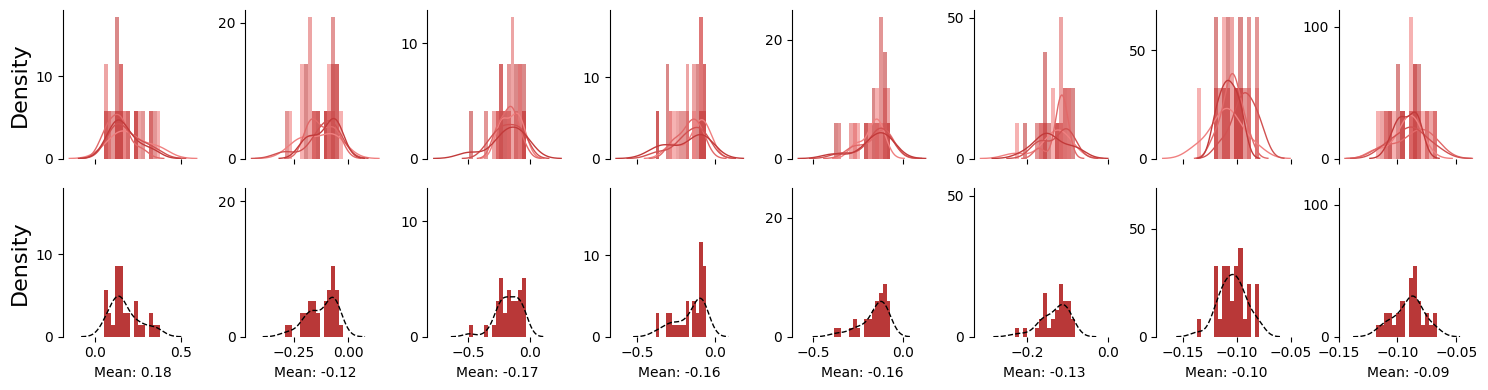

In [74]:
import seaborn as sns

colors = color_space(5)

def plot_curvature_dist(curvature_dict):
    cmerged = {}
    bins = {}

    # Create 2x8 grid (instead of 5x8)
    fig, axs = plt.subplots(2, 8, figsize=(15, 4), sharex='col', sharey='col')

    all_data = []
    for layer in range(8):
        cmerged[layer] = []
        for s in range(4):
            clist = np.log10(curvature_dict[s][layer])
            cmerged[layer].extend(clist)
            all_data.extend(clist)
        bins[layer] = np.histogram_bin_edges(cmerged[layer], bins=15)

    for layer in range(8):
        # First row: Combined plot of first 4 subjects
        for s in range(4):
            clist = np.log10(curvature_dict[s][layer])
            # Plot each subject with individual colors (semi-transparent)
            axs[0, layer].hist(clist, bins=bins[layer], color=colors[s], alpha=0.6, density=True)
            sns.kdeplot(clist, ax=axs[0, layer], color=colors[s], linewidth=1)
        
        # Second row: Merged data (original last row)
        axs[1, layer].hist(cmerged[layer], bins=bins[layer], color=colors[-1], alpha=0.9, density=True)
        sns.kdeplot(cmerged[layer], ax=axs[1, layer], color='k', linewidth=1, linestyle='--')
        axs[1, layer].set_xlabel(f'Mean: {np.mean(cmerged[layer]):.2f}', y=-0.25)

    # Axis formatting
    for ax in axs.flatten():
        ax.set_ylabel('')
        ax.locator_params(axis='y', nbins=2)
        ax.locator_params(axis='x', nbins=3)
        ax.spines['top'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
        ax.spines['right'].set_visible(False)
    
    # Set y-labels for leftmost plots
    axs[0, 0].set_ylabel('Density', fontsize=16)
    axs[1, 0].set_ylabel('Density', fontsize=16)
    
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.2, wspace=0.3)  # Adjusted spacing
    plt.show()

plot_curvature_dist(last_curv_of_lr[1.])

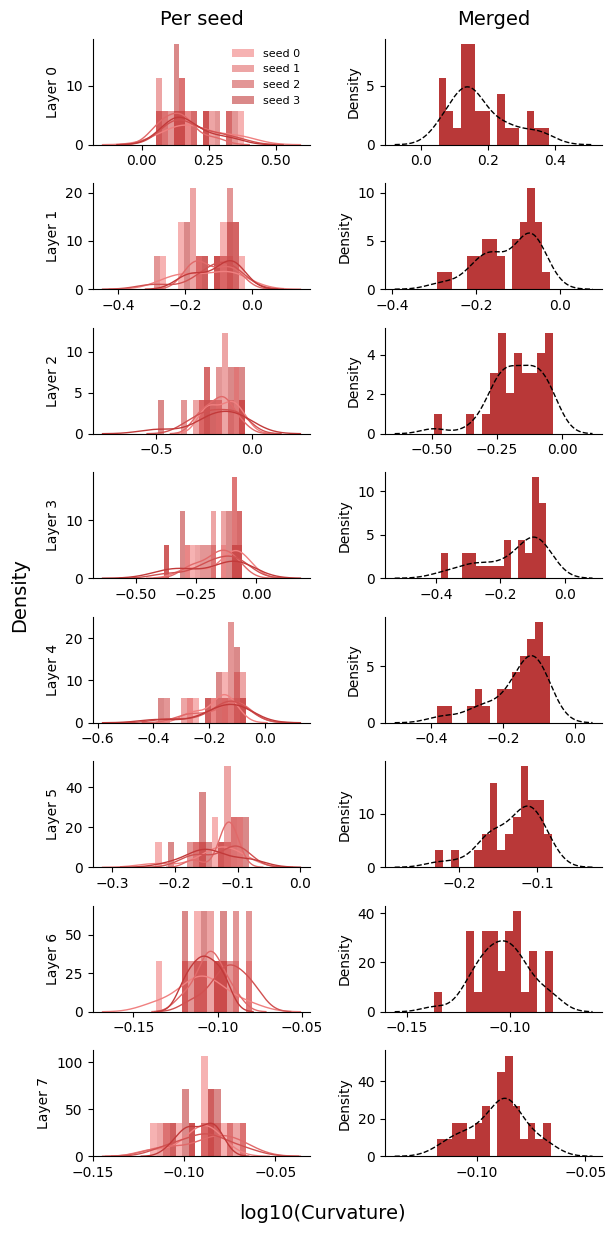

In [ ]:
import seaborn as sns

colors = color_space(5)

def plot_curvature_dist(curvature_dict):
    cmerged = {}
    bins = {}

    # Create 8x2 grid (layers as rows)
    fig, axs = plt.subplots(8, 2, figsize=(6, 12))
    
    # Precompute bins and merged data
    for layer in range(8):
        cmerged[layer] = []
        for s in range(4):
            clist = np.log10(curvature_dict[s][layer])
            cmerged[layer].extend(clist)
        bins[layer] = np.histogram_bin_edges(cmerged[layer], bins=15)

    # Plot each layer in a row
    for layer in range(8):
        # Left column: Combined subjects (s0-s3)
        for s in range(4):
            clist = np.log10(curvature_dict[s][layer])
            axs[layer, 0].hist(clist, bins=bins[layer], color=colors[s], 
                               alpha=0.6, label=f'seed {s}')
            sns.kdeplot(clist, ax=axs[layer, 0], color=colors[s], linewidth=1)
        
        # Right column: Merged data
        axs[layer, 1].hist(cmerged[layer], bins=bins[layer], 
                          color=colors[-1], alpha=0.9, 
                          label=f'Mean: {np.mean(cmerged[layer]):.2f}')
        sns.kdeplot(cmerged[layer], ax=axs[layer, 1], 
                   color='k', linewidth=1, linestyle='--')
        
        # Add layer label to leftmost plot
        axs[layer, 0].set_ylabel(f'Layer {layer}', fontsize=10)
    
    # Formatting
    for ax_row in axs:
        for ax in ax_row:
            ax.locator_params(axis='y', nbins=3)
            ax.locator_params(axis='x', nbins=4)
            for spine in ['top', 'right']:
                ax.spines[spine].set_visible(False)
    
    # Add column headers
    axs[0, 0].set_title('Per seed', fontsize=14, pad=10)
    axs[0, 1].set_title('Merged', fontsize=14, pad=10)
    
    # Add legend to first plot
    axs[0, 0].legend(fontsize=8, frameon=False)
    
    # Global labels
    fig.text(0.5, -0.02, 'log10(Curvature)', ha='center', fontsize=14)
    fig.text(-0.02, 0.5, 'Density', va='center', 
             rotation='vertical', fontsize=14)
    
    plt.tight_layout()
    # plt.subplots_adjust(hspace=0.15, wspace=0.2, bottom=0.05, top=0.95, left=0.1, right=0.95)
    plt.show()

plot_curvature_dist(last_curv_of_lr[1.])

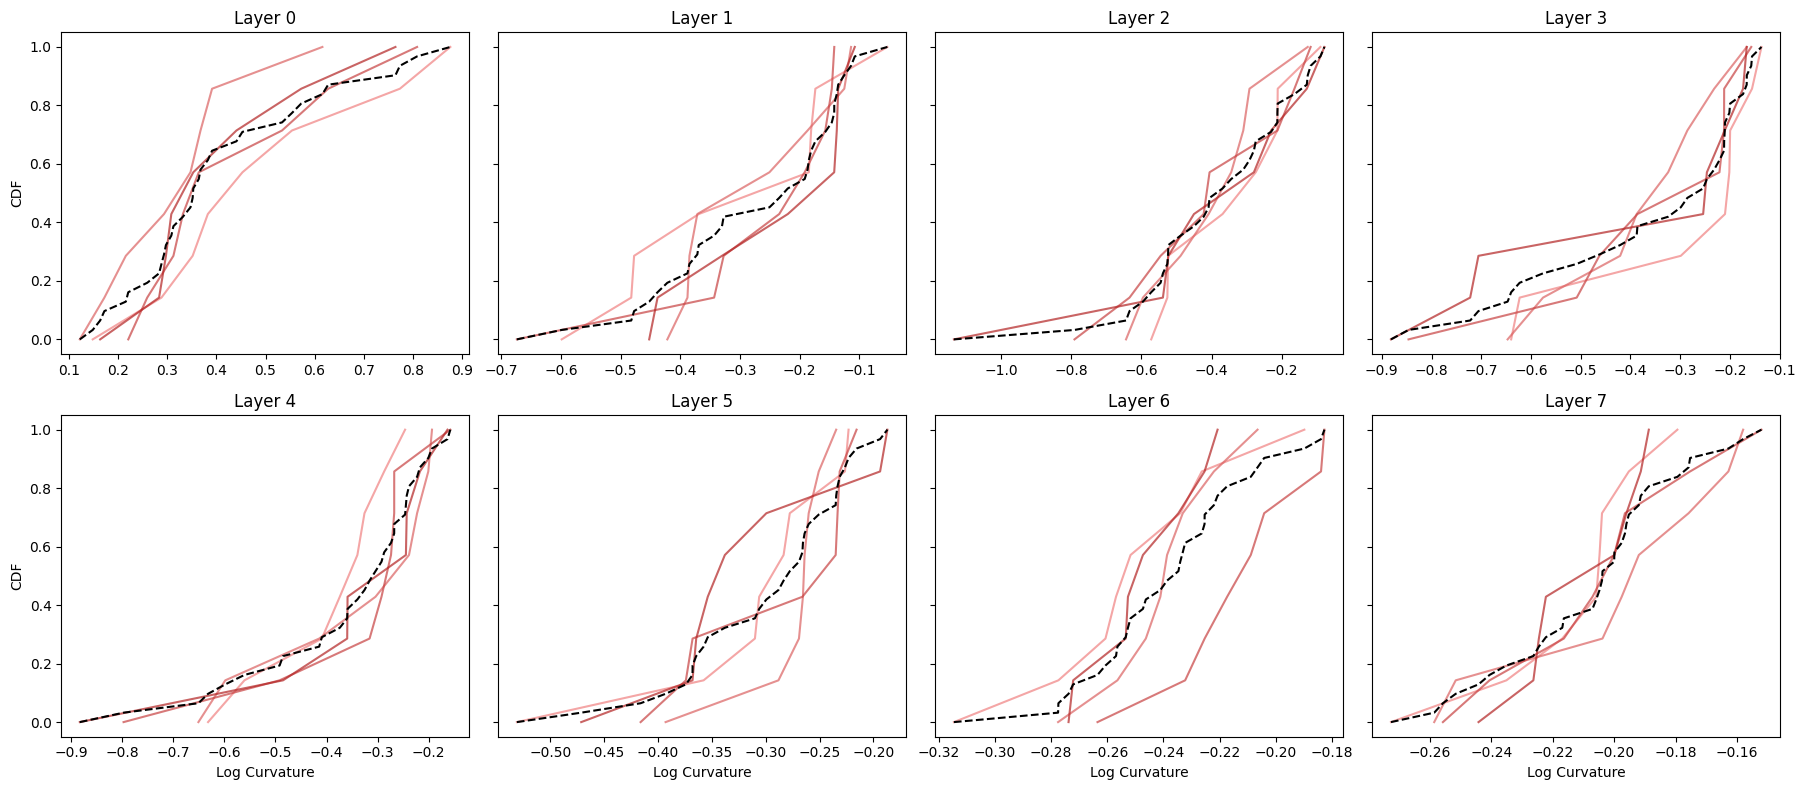

In [ ]:
colors4 = color_space(4)

lr=1.

fig, axs = plt.subplots(2, 4, figsize=(18, 8), sharey='row')
axs = axs.flatten()
all_data = []
for layer in range(8):
    layer_data = []
    for s in range(4):
        clist = np.log(last_curv_of_lr[lr][s][layer])
        layer_data.extend(clist)
        sorted_data = np.sort(clist)
        yvals = np.arange(len(sorted_data)) / float(len(sorted_data) - 1)
        axs[layer].plot(sorted_data, yvals, color=colors4[s], alpha=0.7)
    
    sorted_data = np.sort(layer_data)
    yvals = np.arange(len(sorted_data)) / float(len(sorted_data) - 1)
    axs[layer].plot(sorted_data, yvals, 'k--')
    axs[layer].set_title(f'Layer {layer}')
    if (layer % 4) == 0:
        axs[layer].set_ylabel('CDF')
    if layer >= 4:
        axs[layer].set_xlabel('Log Curvature')

plt.tight_layout()
plt.show()

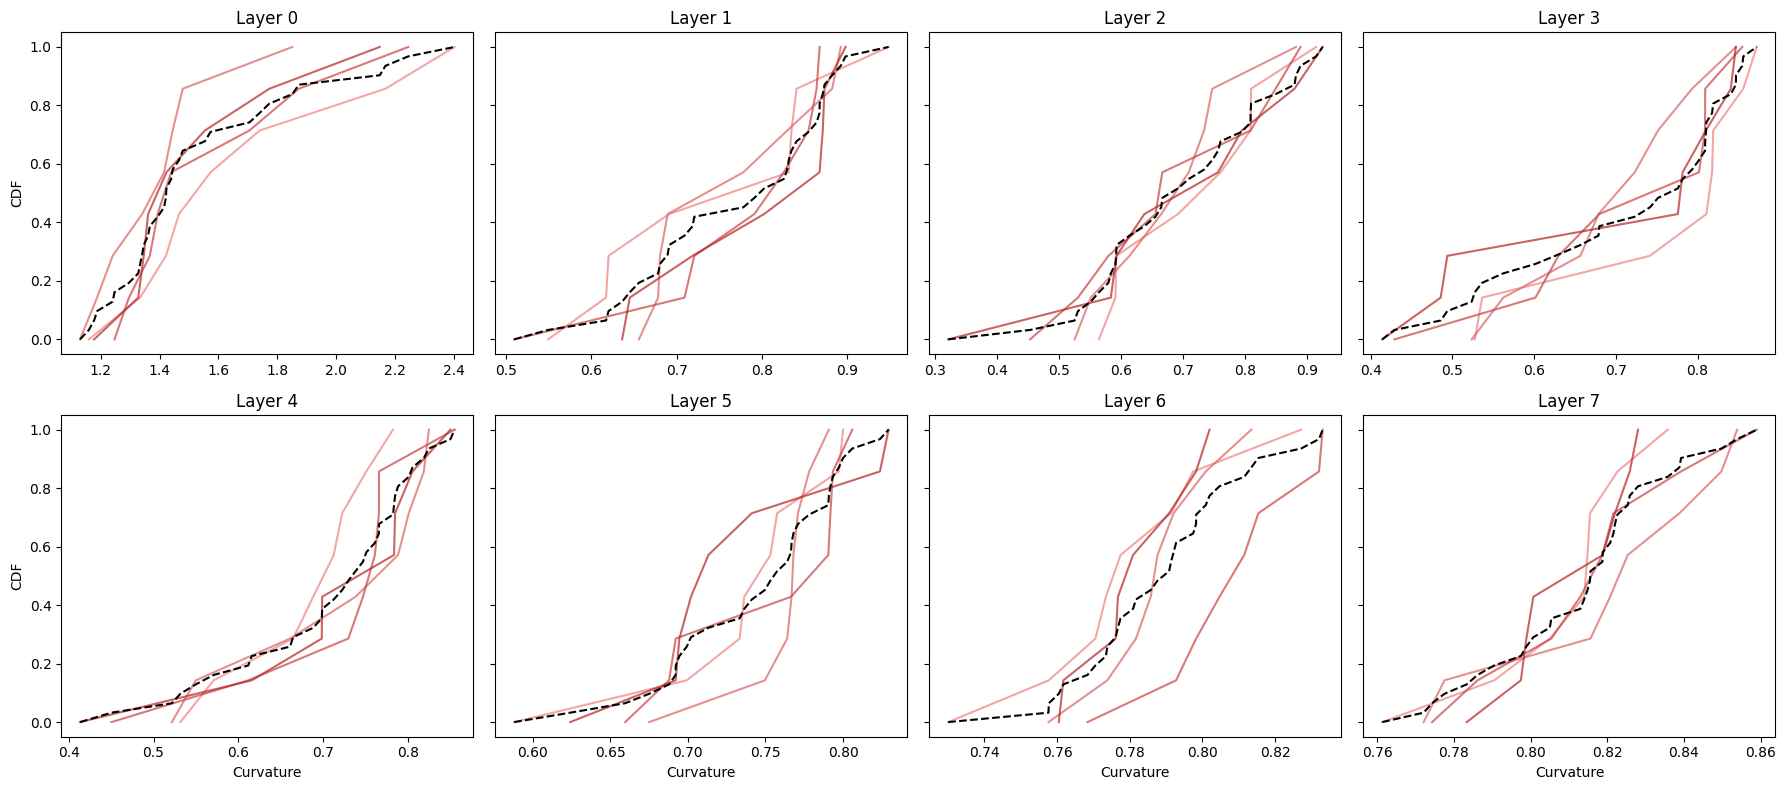

In [48]:
colors4 = color_space(4)

lr=1.

fig, axs = plt.subplots(2, 4, figsize=(18, 8), sharey='row')
axs = axs.flatten()
all_data = []
for layer in range(8):
    layer_data = []
    for s in range(4):
        clist = last_curv_of_lr[lr][s][layer]
        layer_data.extend(clist)
        sorted_data = np.sort(clist)
        yvals = np.arange(len(sorted_data)) / float(len(sorted_data) - 1)
        axs[layer].plot(sorted_data, yvals, color=colors4[s], alpha=0.7)
    
    sorted_data = np.sort(layer_data)
    yvals = np.arange(len(sorted_data)) / float(len(sorted_data) - 1)
    axs[layer].plot(sorted_data, yvals, 'k--')
    axs[layer].set_title(f'Layer {layer}')
    if (layer % 4) == 0:
        axs[layer].set_ylabel('CDF')
    if layer >= 4:
        axs[layer].set_xlabel('Curvature')

plt.tight_layout()
plt.show()

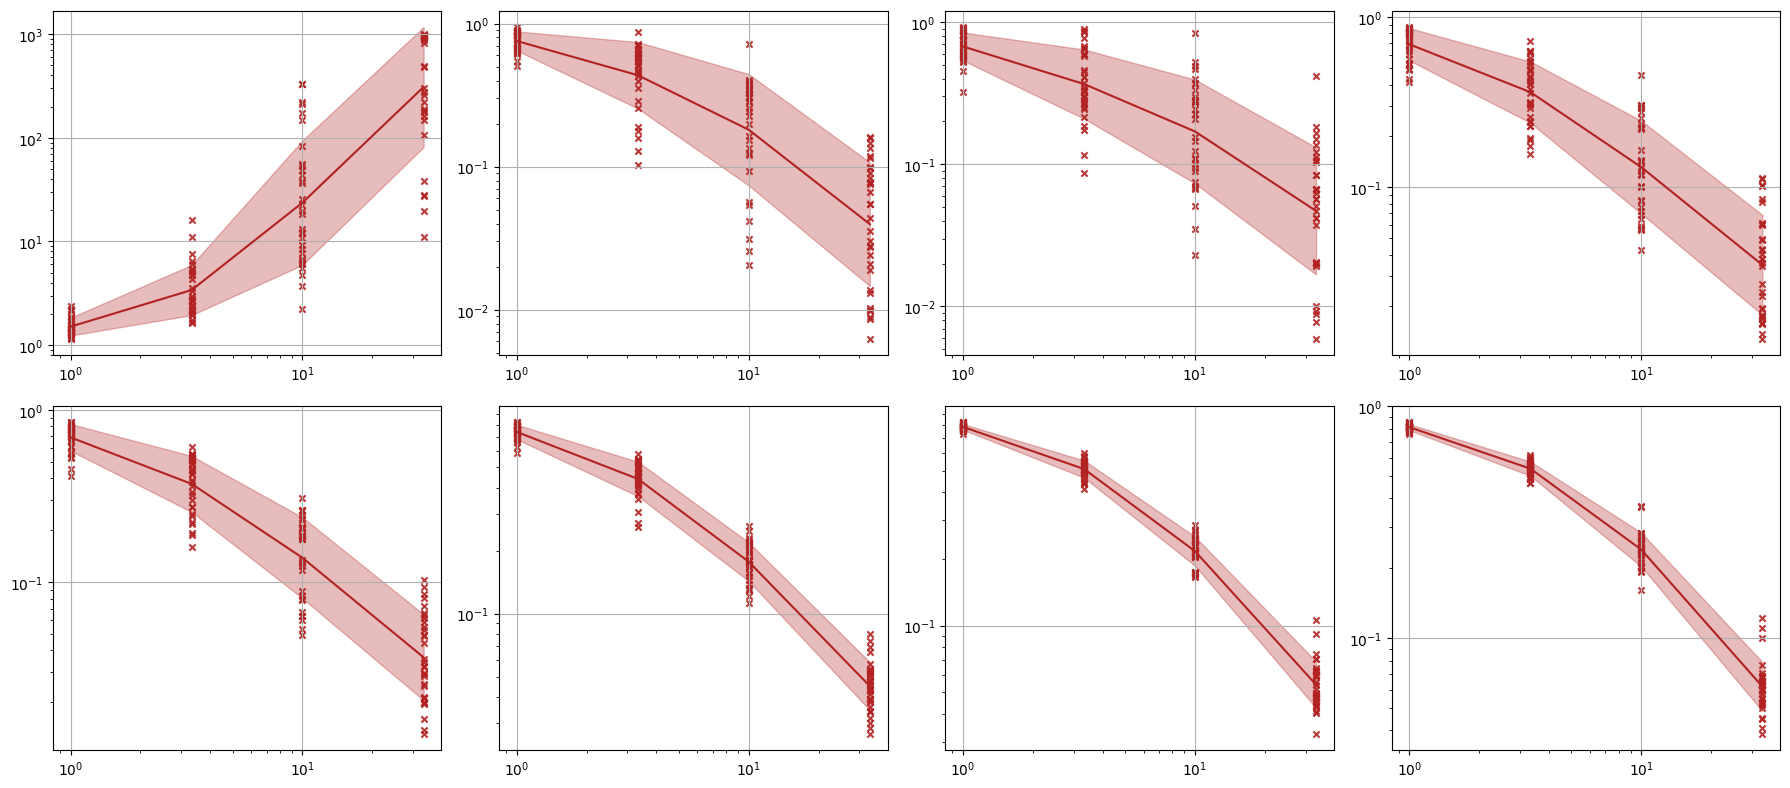

In [84]:
lrs = [1., 3.33, 10., 33.3]

fig, axs = plt.subplots(2, 4, figsize=(18, 8))
axs = axs.flatten()
for layer, ax in enumerate(axs):
    me, va = [], []
    for lr in lrs:
        clist = np.array([last_curv_of_lr[lr][s][layer] for s in range(4)]).flatten()
        ax.scatter([lr]*len(clist), clist, color=c, s=20, marker='x', alpha=0.9)
        log_c_m = np.mean(np.log(clist))
        log_c_v = np.std(np.log(clist))
        me.append(log_c_m)
        va.append(log_c_v)
    me, va = np.array(me), np.array(va)
    ax.plot(lrs, np.exp(me), color='firebrick')
    ax.fill_between(lrs,
                    np.exp(me - va),
                    np.exp(me + va),
                    alpha=0.3, color='firebrick')

    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.grid(True)

plt.tight_layout()
plt.show()

#### Tinystories

In [92]:
keys = ['tsc_eh_lr1', 'tsc_eh_lr10']
curvature_dict = {}

for k in keys:
    pattern = re.compile(f"{k}_1.35M.*/tensorboard_logs")
    matching_dirs = get_dirs(pattern)

Matched directories:
../runs/05.29/68488_tsc_eh_lr1_1.35M_s1/tensorboard_logs
../runs/05.29/74582_tsc_eh_lr1_1.35M_s2/tensorboard_logs
../runs/05.29/80680_tsc_eh_lr1_1.35M_s3/tensorboard_logs
../runs/05.29/62392_tsc_eh_lr1_1.35M_s0/tensorboard_logs
Matched directories:
../runs/05.30/00374_tsc_eh_lr10_1.35M_s0/tensorboard_logs
../runs/05.30/06476_tsc_eh_lr10_1.35M_s1/tensorboard_logs
../runs/05.30/12576_tsc_eh_lr10_1.35M_s2/tensorboard_logs
../runs/05.30/18677_tsc_eh_lr10_1.35M_s3/tensorboard_logs


In [109]:
n_heads = 12
n_layers = 12

curv_of_lr = {}
last_curv_of_lr = {}

for lr, k in zip(
    [1., 10.],
    ['tsc_eh_lr1', 'tsc_eh_lr10']
):
    print('\n', lr)
    pattern = re.compile(f"{k}_1.35M.*/tensorboard_logs")
    matching_dirs = get_dirs(pattern)

    curv_of_seed = {}
    last_curv_of_seed = {}

    for dir in matching_dirs:
        s = parse_seed(dir)
        print(f"Seed: {s}")
        curv_dict = get_curvatures(dir)
        curv_arr = np.array([[curv_dict[l][h][1] for h in range(n_heads)] for l in range(n_layers)])
        last_curv_arr = np.array([[curv_dict[l][h][1][-1] for h in range(n_heads)] for l in range(n_layers)])
        curv_of_seed[s] = curv_arr
        last_curv_of_seed[s] = last_curv_arr

    curv_of_lr[lr] = curv_of_seed
    last_curv_of_lr[lr] = last_curv_of_seed


 1.0
Matched directories:
../runs/05.29/68488_tsc_eh_lr1_1.35M_s1/tensorboard_logs
../runs/05.29/74582_tsc_eh_lr1_1.35M_s2/tensorboard_logs
../runs/05.29/80680_tsc_eh_lr1_1.35M_s3/tensorboard_logs
../runs/05.29/62392_tsc_eh_lr1_1.35M_s0/tensorboard_logs
Seed: 1
Seed: 2
Seed: 3
Seed: 0

 10.0
Matched directories:
../runs/05.30/00374_tsc_eh_lr10_1.35M_s0/tensorboard_logs
../runs/05.30/06476_tsc_eh_lr10_1.35M_s1/tensorboard_logs
../runs/05.30/12576_tsc_eh_lr10_1.35M_s2/tensorboard_logs
../runs/05.30/18677_tsc_eh_lr10_1.35M_s3/tensorboard_logs
Seed: 0
Seed: 1
Seed: 2
Seed: 3


In [ ]:
# with open('tinystories_char_curvatures.pkl', 'wb') as file:
#     pickle.dump(curv_of_lr, file, protocol=pickle.HIGHEST_PROTOCOL)

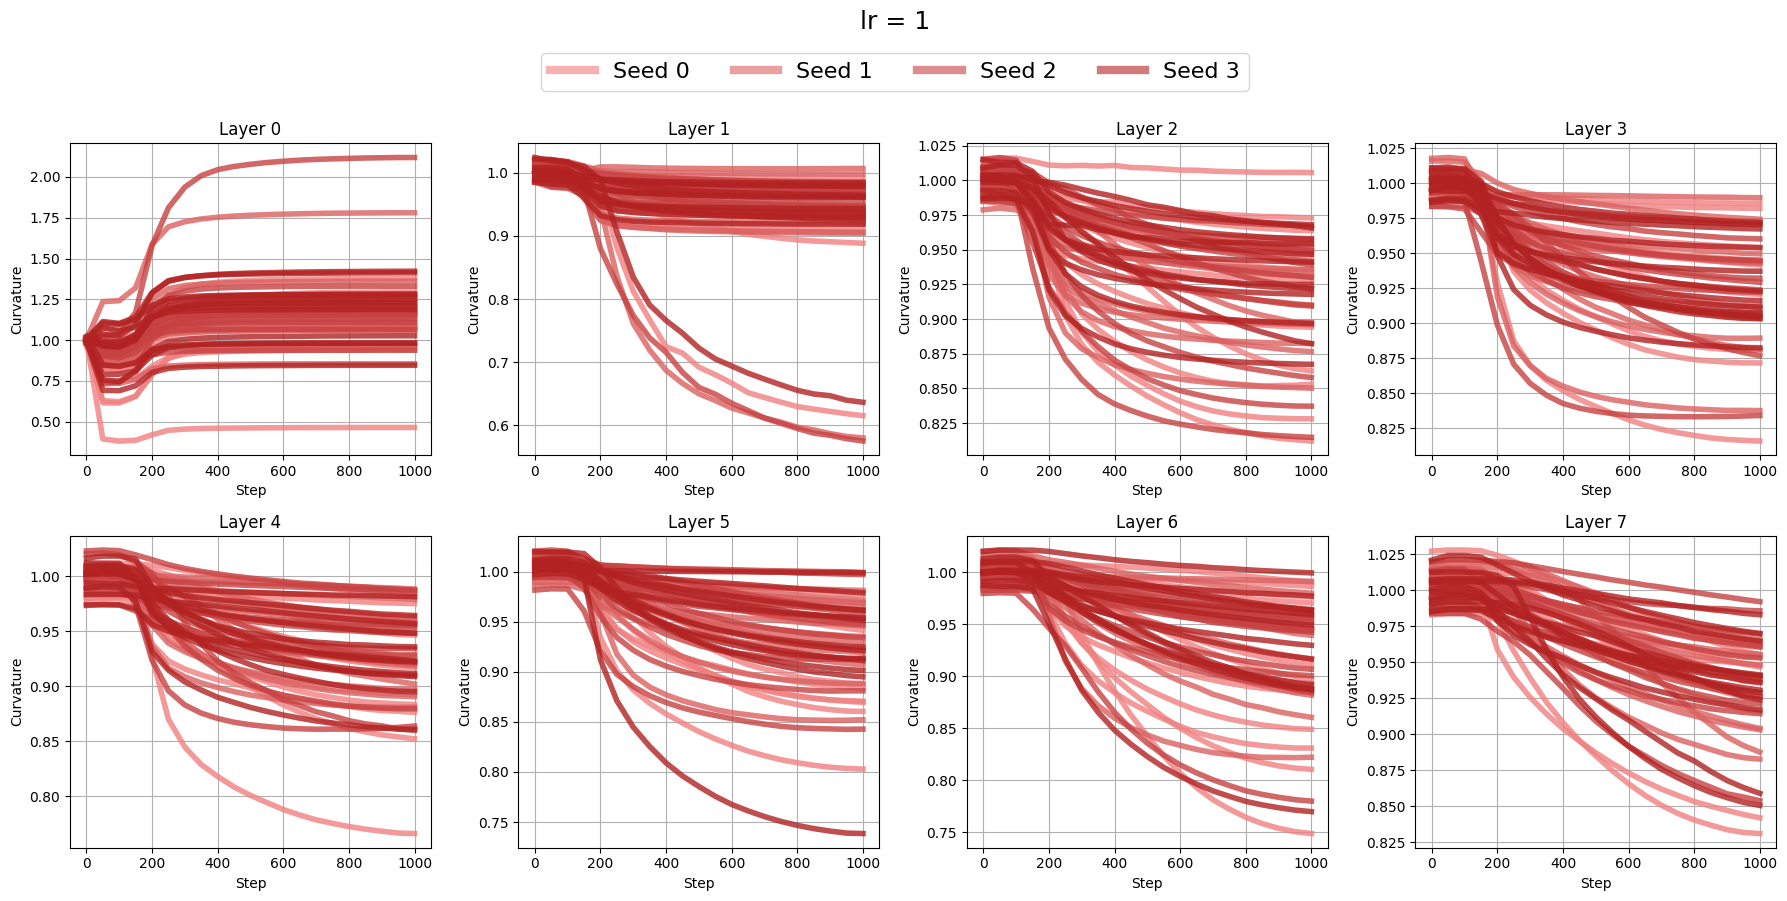

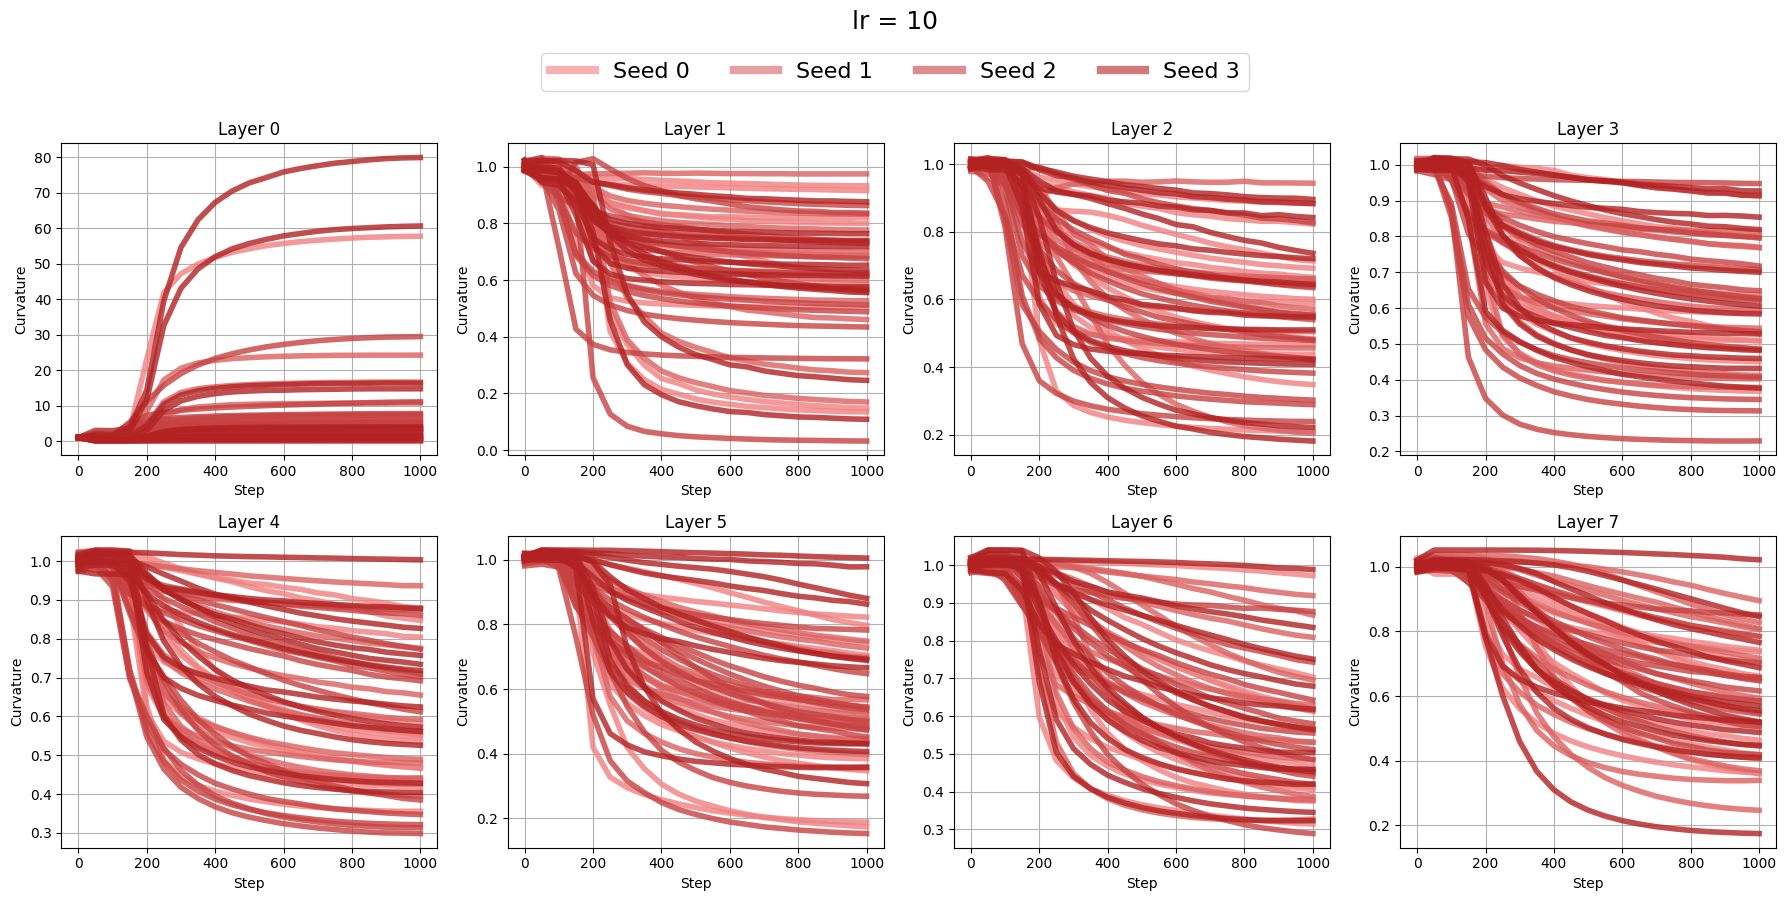

In [111]:
for lr, curv_of_seed in curv_of_lr.items():

    fig, axs = plt.subplots(2, 4, figsize=(18, 8))
    axs = axs.flatten()
    for layer, ax in enumerate(axs):
        for s, c in enumerate(colors):
            plot_layer_curvatures(ax, curv_of_seed[s][layer], title=f"Layer {layer}", color=c, alpha=0.8, lw=4)

    seed_labels = [f"Seed {s}" for s in range(num_colors)]

    legend_handles = [
        Line2D([0], [0], color=c, lw=6, alpha=0.6, label=label)
        for c, label in zip(colors, seed_labels)
    ]

    fig.legend(handles=legend_handles, loc='upper center', ncol=4, fontsize=16, bbox_to_anchor=(0.5, 1.08))

    plt.tight_layout()
    plt.suptitle(f"lr = {lr:.0f}", y=1.12, fontsize=18)
    plt.show()

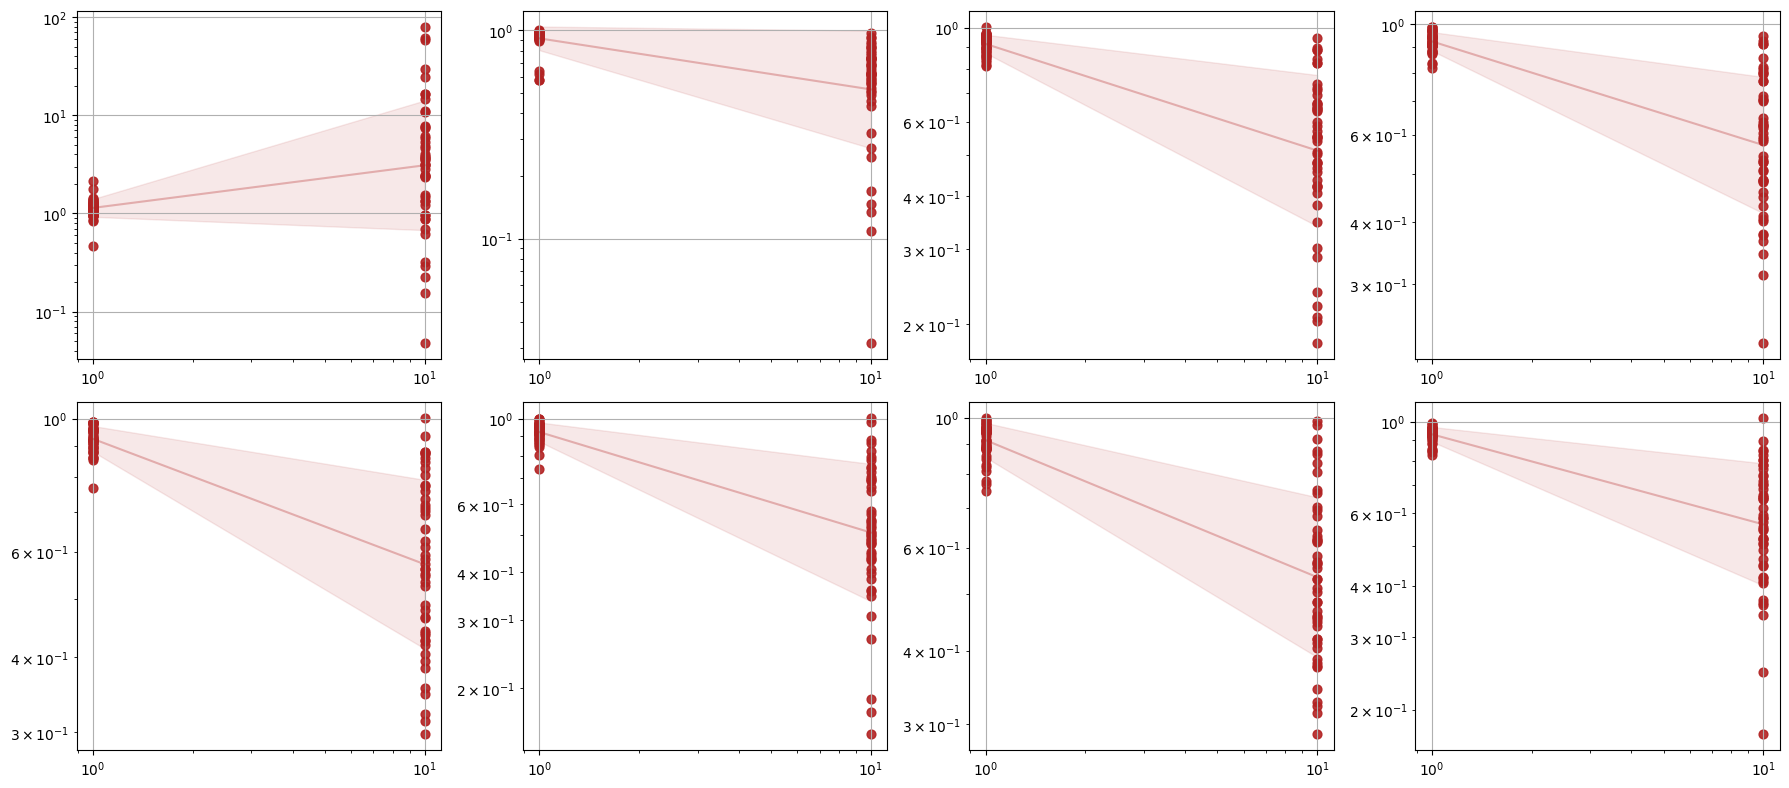

In [112]:
lrs = [1., 10.]

fig, axs = plt.subplots(2, 4, figsize=(18, 8))
axs = axs.flatten()
for layer, ax in enumerate(axs):
    me, va = [], []
    for lr in lrs:
        clist = np.array([last_curv_of_lr[lr][s][layer] for s in range(4)]).flatten()
        ax.scatter([lr]*len(clist), clist, color=c, s=40, marker='o', alpha=0.9)
        log_c_m = np.mean(np.log(clist))
        log_c_v = np.std(np.log(clist))
        me.append(log_c_m)
        va.append(log_c_v)
    me, va = np.array(me), np.array(va)
    ax.plot(lrs, np.exp(me), color='firebrick', alpha=0.3)
    ax.fill_between(lrs,
                    np.exp(me - va),
                    np.exp(me + va),
                    alpha=0.1, color='firebrick')

    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.grid(True)

plt.tight_layout()
plt.show()

#### Fineweb

In [113]:
keys = ['fwe_eh_lr1_38.3', 'fwe_eh_lr10_24.6']
# keys = ['fwe_eh']
for k in keys:
    pattern = re.compile(f"{k}.*/tensorboard_logs")
    matching_dirs = get_dirs(pattern)

Matched directories:
../runs/05.29/65280_fwe_eh_lr1_38.3M_s0/tensorboard_logs
Matched directories:
../runs/05.29/13298_fwe_eh_lr10_24.6M_s1/tensorboard_logs


In [115]:
curv_of_sz = {}
last_curv_of_sz = {}

for sz, k, (n_heads, n_layers) in zip(
    [24.6, 38.3],
    ['fwe_eh_lr10_24.6', 'fwe_eh_lr1_38.3'],
    [(12, 12), (16, 16)]
):
    print('\n', sz)
    pattern = re.compile(f"{k}.*/tensorboard_logs")
    matching_dirs = get_dirs(pattern)

    curv_of_seed = {}
    last_curv_of_seed = {}

    for dir in matching_dirs:
        s = parse_seed(dir)
        print(f"Seed: {s}")
        curv_dict = get_curvatures(dir)
        curv_arr = np.array([[curv_dict[l][h][1] for h in range(n_heads)] for l in range(n_layers)])
        last_curv_arr = np.array([[curv_dict[l][h][1][-1] for h in range(n_heads)] for l in range(n_layers)])
        curv_of_seed[s] = curv_arr
        last_curv_of_seed[s] = last_curv_arr

    curv_of_sz[sz] = curv_arr
    last_curv_of_sz[sz] = last_curv_of_seed


 24.6
Matched directories:
../runs/05.29/13298_fwe_eh_lr10_24.6M_s1/tensorboard_logs
Seed: 1

 38.3
Matched directories:
../runs/05.29/65280_fwe_eh_lr1_38.3M_s0/tensorboard_logs
Seed: 0


In [116]:
with open('fineweb_curvatures.pkl', 'wb') as file:
    pickle.dump(curv_of_sz, file, protocol=pickle.HIGHEST_PROTOCOL)

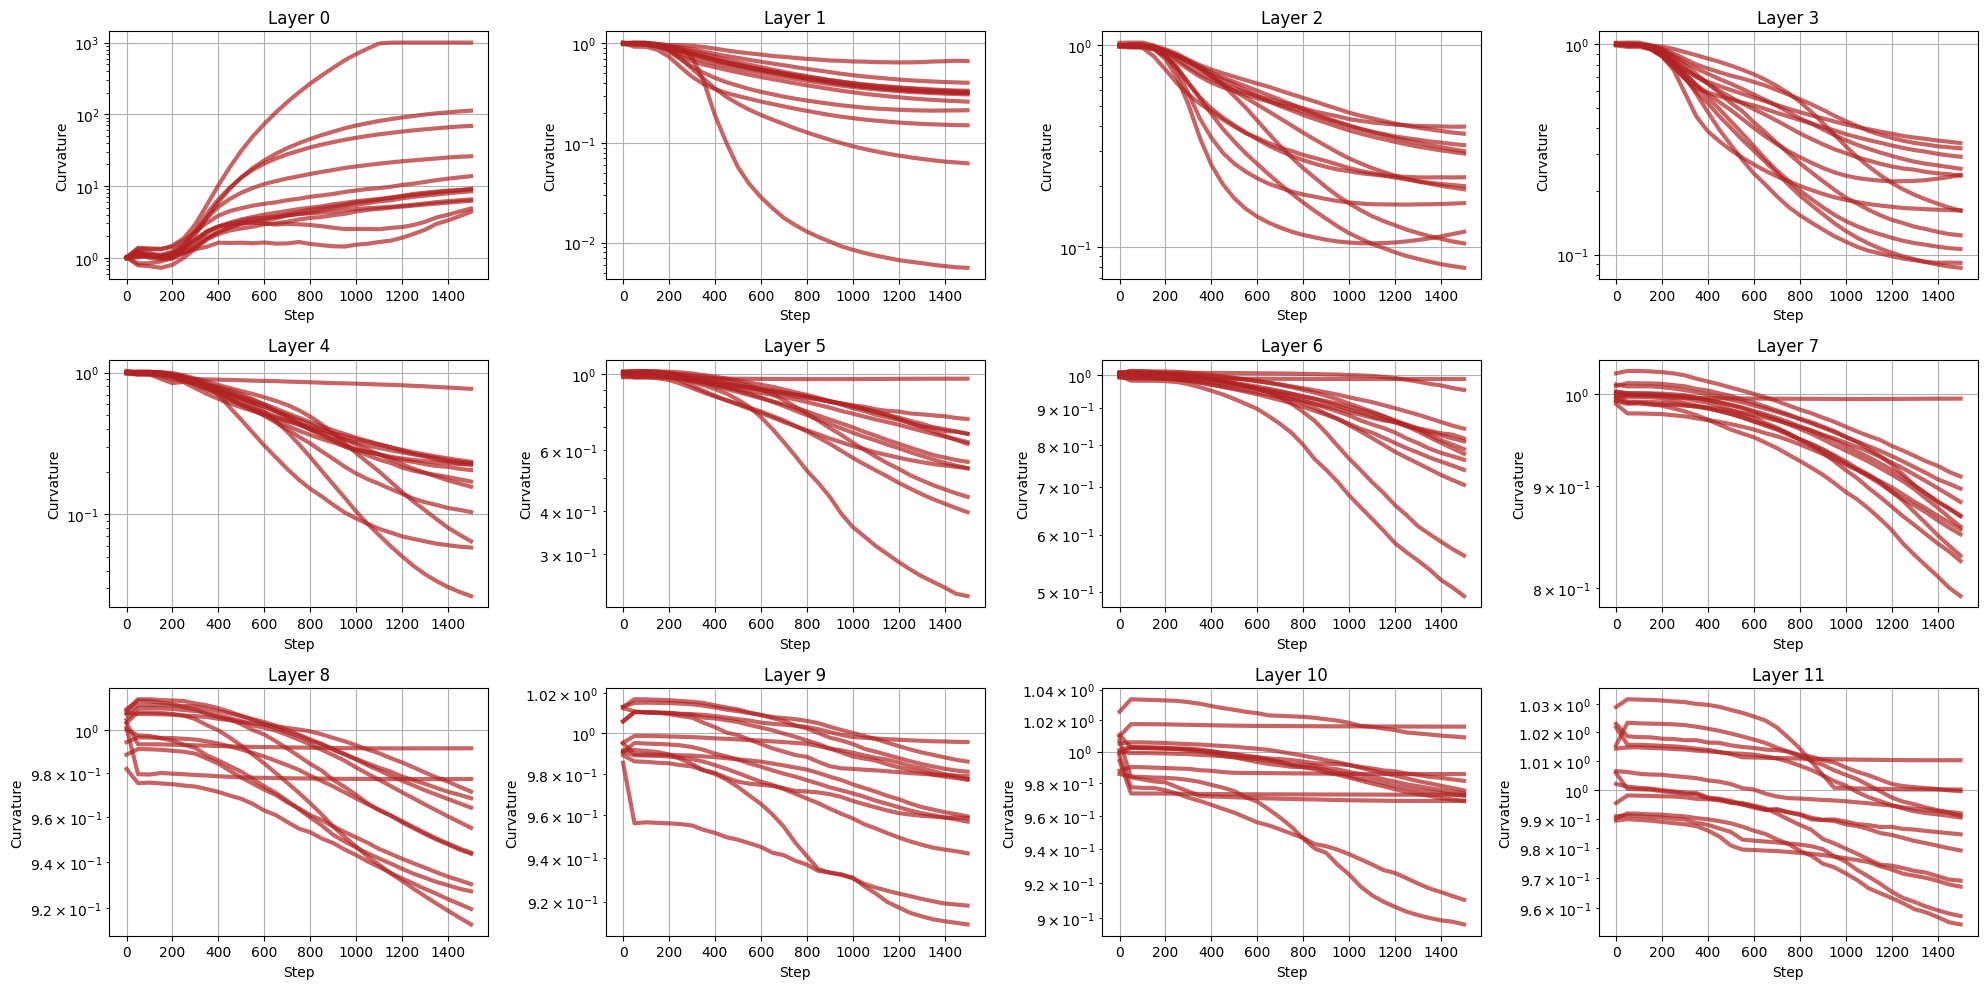

In [123]:
curv = curv_of_sz[24.6][1]
fig, axs = plt.subplots(3, 4, figsize=(20, 10))

for layer, ax in enumerate(axs.flatten()):
    plot_layer_curvatures(ax, curv[layer], title=f"Layer {layer}", color='firebrick', alpha=0.7, lw=3, yscale='log')

plt.tight_layout()
plt.show()

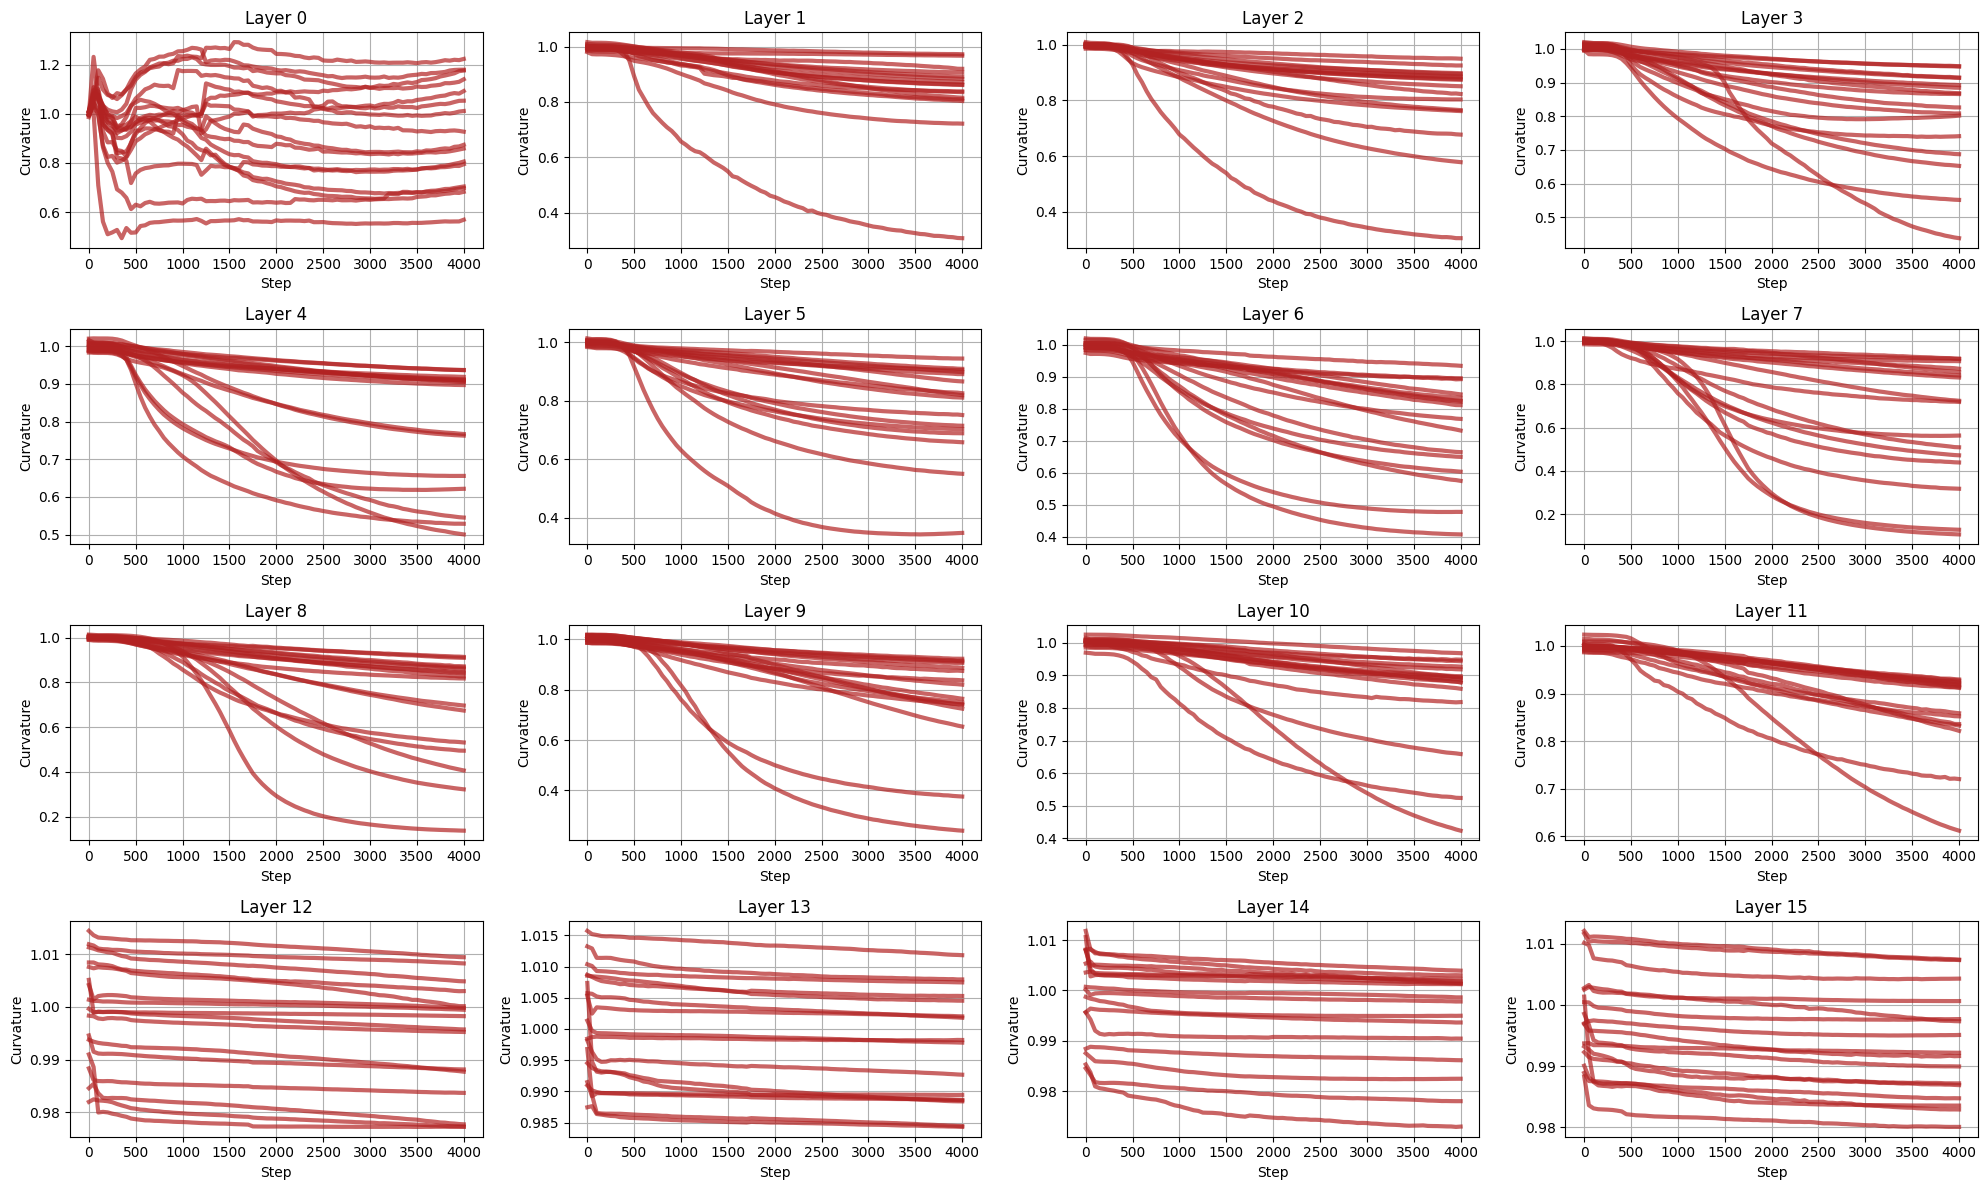

In [124]:
curv = curv_of_sz[38.3][0]
fig, axs = plt.subplots(4, 4, figsize=(20, 12))

for layer, ax in enumerate(axs.flatten()):
    plot_layer_curvatures(ax, curv[layer], title=f"Layer {layer}", color='firebrick', alpha=0.7, lw=3)

plt.tight_layout()
plt.show()